## Rappel Google Colab

Tout d'abord, sélectionnez l'option GPU de Colab avec *Edit > Notebook settings* et sélectionner GPU comme Hardware accelerator.
Installer ensuite deeplib avec la commande suivante:

In [1]:
!pip install git+https://github.com/ulaval-damas/glo4030-labs.git

  Cloning https://github.com/ulaval-damas/glo4030-labs.git to /tmp/pip-req-build-22fmuch4
  Running command git clone --filter=blob:none --quiet https://github.com/ulaval-damas/glo4030-labs.git /tmp/pip-req-build-22fmuch4
  Resolved https://github.com/ulaval-damas/glo4030-labs.git to commit c18815c2c3080b82b6db4c66f66a57367149a723
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 69.4 MB/s eta 0:00:00
  Created wheel for deeplib: filename=deeplib-0.1-py3-none-any.whl size=10542 sha256=586b5dc051bbeaeb624e5868fe8ba2e755fd55eb929c4669a7a0f9155f45a5f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-j7ra_i35/wheels/9f/29/ed/25822e0088ad9c46b352ed51c58696b9d13fbc94e1db2ac759
Successfully built deeplib


# Laboratoire 4: Régularisation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import poutyne as pt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from deeplib.datasets import load_cifar10, load_mnist, train_valid_loaders
from deeplib.net import CifarNet, CifarNetBatchNorm
from deeplib.training import train, test

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

cifar_train, cifar_test = load_cifar10()
mnist_train, mnist_test = load_mnist()

100%|██████████| 170M/170M [00:08<00:00, 20.3MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.74MB/s]


## Partie 1: Régularisation L1 et L2

### Implémentation manuelle
Dans la communauté de l'apprentissage profond, la régularisation L2 est communément appelée **weight decay**.

Il est toutefois à noter que le **weight decay** et la régularisation L2 ne sont pas équivalents dans tous les cas. Ces deux méthodes sont équivalentes lorsque l'on utilise un optimiseur de type SGD, mais elles ne le sont pas pour des optimiseurs à gradients adaptatifs comme Adam. Voir l'article [Decoupled Weight Decay Regularization](https://arxiv.org/pdf/1711.05101.pdf) pour plus de détails sur la distinction entre ces deux méthodes.

Dans le cadre de ce laboratoire, on utilise exclusivement l'optimiseur SGD, on peut donc considérer les termes **weight decay** et la régularisation L2 comme équivalents.

Dans PyTorch, les optimiseurs de `torch.optim` ont un paramètre `weight_decay` pour utiliser cette régularisation. Par contre, on peut facilement implémenter manuellement la régularisation L2 comme une pénalité sur la norme des poids (voir le [chapitre 7.1](http://www.deeplearningbook.org/contents/regularization.html)).

#### Exercice
 - Complétez la fonction *loss_init* en ajoutant manuellement la pénalité sur les paramètres du réseau selon une régularisation L1 ou L2. Le paramètre *reg_alpha* correspond à l'hyperparamètre de régularisation $\alpha$ du livre ($\lambda$ dans les acétates du cours). Le paramètre *p* correspond à l'ordre de la norme: $p=1$ pour la norme L1 et $p=2$ pour la norme L2.

In [4]:
def loss_init(parameters=[], reg_alpha=0, p=2):
    cross_entropy = nn.CrossEntropyLoss()

    def loss_function(output, targets):
        loss = cross_entropy(output,targets)

        for param in parameters:
            # TODO Ajoutez la pénalité sur les paramètres
            param_norm = torch.norm(param, p=p)
            loss += reg_alpha * param_norm

        return loss
    return loss_function

Testez votre implémentation de la régularisation par la norme L2 ($p=2$):

In [5]:
torch.manual_seed(42)
net = CifarNet()

optimizer = optim.SGD(net.parameters(), lr=0.1)
loss = loss_init(list(net.parameters()), reg_alpha=1e-3, p=2)

history = train(net, optimizer, cifar_train, n_epoch=5, batch_size=64, use_gpu=True, criterion=loss)

/usr/local/lib/python3.12/dist-packages/poutyne/framework/metrics/decomposable.py:59: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  values = [float(output)]


Epoch: 1/5 Train steps: 625 Val steps: 157 10.87s loss: 1.923338 acc: 31.070000 val_loss: 1.577238 val_acc: 44.140000
Epoch: 2/5 Train steps: 625 Val steps: 157 9.66s loss: 1.451664 acc: 49.157500 val_loss: 1.360738 val_acc: 53.050000
Epoch: 3/5 Train steps: 625 Val steps: 157 9.52s loss: 1.250064 acc: 56.867500 val_loss: 1.256839 val_acc: 57.440000
Epoch: 4/5 Train steps: 625 Val steps: 157 9.34s loss: 1.095824 acc: 62.917500 val_loss: 1.093754 val_acc: 63.130000
Epoch: 5/5 Train steps: 625 Val steps: 157 9.66s loss: 0.971743 acc: 67.330000 val_loss: 1.020252 val_acc: 66.140000


Testez votre implémentation de la régularisation par la norme L1 ($p=1$):

In [6]:
torch.manual_seed(42)
net = CifarNet()
optimizer = optim.SGD(net.parameters(), lr=0.1)
loss = loss_init(list(net.parameters()), reg_alpha=1e-3, p=1)

history = train(net, optimizer, cifar_train, n_epoch=5, batch_size=64, use_gpu=True, criterion=loss)

Epoch: 1/5 Train steps: 625 Val steps: 157 10.00s loss: 2.773228 acc: 20.617500 val_loss: 2.114823 val_acc: 28.460000
Epoch: 2/5 Train steps: 625 Val steps: 157 10.06s loss: 2.090209 acc: 27.200000 val_loss: 1.991987 val_acc: 32.260000
Epoch: 3/5 Train steps: 625 Val steps: 157 11.12s loss: 1.951616 acc: 34.402500 val_loss: 1.895198 val_acc: 36.600000
Epoch: 4/5 Train steps: 625 Val steps: 157 10.05s loss: 1.849778 acc: 38.627500 val_loss: 1.834303 val_acc: 40.660000
Epoch: 5/5 Train steps: 625 Val steps: 157 9.16s loss: 1.809990 acc: 40.222500 val_loss: 1.779540 val_acc: 42.020000


### Utilisation du *weight decay*

Explorons maintenant l'utilisation du paramètre `weight_decay` disponible dans les optimiseurs de `PyTorch` pour effectuer de la régularisation L2. Nous allons entrainer un réseau de neurones avec régularisation L2 et un autre sans pour pouvoir observer l'impact de la régularisation sur l'apprentissage et le réseau appris.

In [8]:
# Paramètres
batch_size = 64
lr = 0.1
n_epoch = 15

Réseau sans régularisation L2:

Epoch:  1/15 Train steps: 625 Val steps: 157 9.08s loss: 1.911540 acc: 30.802500 val_loss: 1.541034 val_acc: 44.700000
Epoch:  2/15 Train steps: 625 Val steps: 157 9.39s loss: 1.422803 acc: 49.310000 val_loss: 1.323382 val_acc: 53.430000
Epoch:  3/15 Train steps: 625 Val steps: 157 9.43s loss: 1.214235 acc: 57.062500 val_loss: 1.218174 val_acc: 57.800000
Epoch:  4/15 Train steps: 625 Val steps: 157 9.09s loss: 1.055081 acc: 63.105000 val_loss: 1.044882 val_acc: 63.700000
Epoch:  5/15 Train steps: 625 Val steps: 157 8.53s loss: 0.925366 acc: 67.740000 val_loss: 0.982996 val_acc: 66.300000
Epoch:  6/15 Train steps: 625 Val steps: 157 9.61s loss: 0.823687 acc: 71.402500 val_loss: 0.949517 val_acc: 67.520000
Epoch:  7/15 Train steps: 625 Val steps: 157 9.14s loss: 0.732190 acc: 74.702500 val_loss: 0.937331 val_acc: 68.080000
Epoch:  8/15 Train steps: 625 Val steps: 157 9.15s loss: 0.649171 acc: 77.475000 val_loss: 0.989663 val_acc: 67.060000
Epoch:  9/15 Train steps: 625 Val steps: 157 8.6

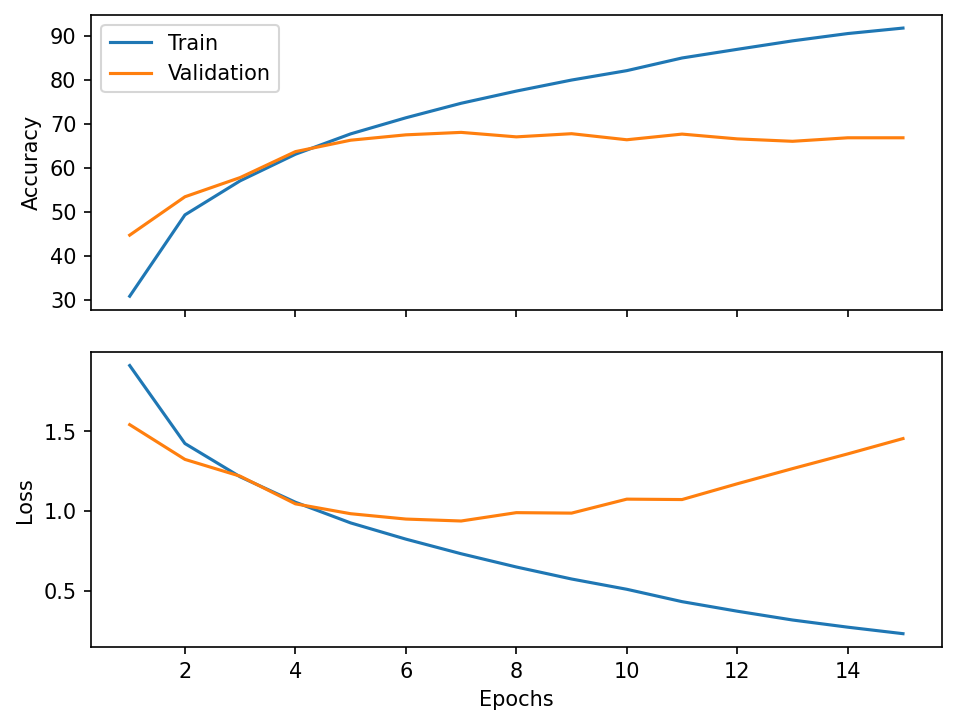

Test steps: 157 1.50s test_loss: 1.394752 test_acc: 67.710000                                 
Précision en test: 67.71


In [9]:
torch.manual_seed(42)
net_without_l2 = CifarNet()
optimizer_without_l2 = optim.SGD(net_without_l2.parameters(), lr=lr, weight_decay=0)

history_without_l2 = train(net_without_l2, optimizer_without_l2, cifar_train, n_epoch, batch_size, use_gpu=True)
history_without_l2.display()
print('Précision en test: {:.2f}'.format(test(net_without_l2, cifar_test, batch_size)))

Réseau avec régularisation L2 (*weight decay*):

Epoch:  1/15 Train steps: 625 Val steps: 157 9.27s loss: 1.969885 acc: 28.720000 val_loss: 1.617212 val_acc: 42.130000
Epoch:  2/15 Train steps: 625 Val steps: 157 9.24s loss: 1.576034 acc: 44.005000 val_loss: 1.470193 val_acc: 47.920000
Epoch:  3/15 Train steps: 625 Val steps: 157 8.64s loss: 1.454911 acc: 48.285000 val_loss: 1.457277 val_acc: 48.970000
Epoch:  4/15 Train steps: 625 Val steps: 157 9.19s loss: 1.382873 acc: 50.780000 val_loss: 1.317596 val_acc: 54.050000
Epoch:  5/15 Train steps: 625 Val steps: 157 9.16s loss: 1.317460 acc: 53.545000 val_loss: 1.282376 val_acc: 55.450000
Epoch:  6/15 Train steps: 625 Val steps: 157 9.20s loss: 1.259347 acc: 55.765000 val_loss: 1.270348 val_acc: 55.520000
Epoch:  7/15 Train steps: 625 Val steps: 157 8.66s loss: 1.220839 acc: 57.105000 val_loss: 1.209124 val_acc: 58.320000
Epoch:  8/15 Train steps: 625 Val steps: 157 9.20s loss: 1.175745 acc: 59.122500 val_loss: 1.191568 val_acc: 58.360000
Epoch:  9/15 Train steps: 625 Val steps: 157 9.1

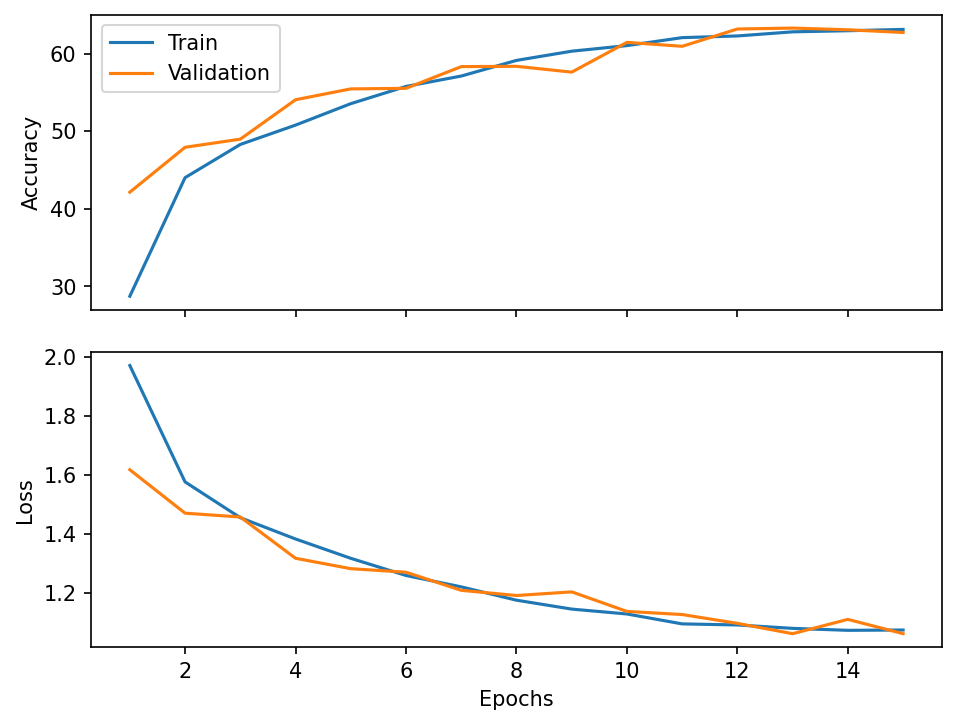

Test steps: 157 2.09s test_loss: 1.053444 test_acc: 63.350000                                 
Précision en test: 63.35


In [16]:
weight_decay = 1e-2

torch.manual_seed(42)
net_l2 = CifarNet()
optimizer_l2 = optim.SGD(net_l2.parameters(), lr=lr, weight_decay=weight_decay)

history_l2 = train(net_l2, optimizer_l2, cifar_train, n_epoch, batch_size, use_gpu=True)
history_l2.display()
print('Précision en test: {:.2f}'.format(test(net_l2, cifar_test, batch_size)))

#### Questions
- Quel est l'effet de la régularisation L2 sur l'entraînement du réseau?

Slows down the network's learning, and lowers overfitting capabilities.
    
- Si vous utilisez un `weight_decay` trop grand (exemple 0.1) qu'arrive-t-il? Pourquoi? Le réseau n'apprend pas puisque la loss est trop grandement modifié et les poids sont ensuite modifiés avec trop d'ampleur.

Dans la cellule suivante, analysez avec un histogramme la distribution des poids appris par les réseaux avec ou sans régularisation.

- Que remarquez-vous?
    
- Essayez d'autres valeurs de weight decay (1e-2, 1e-4) et observez l'impact sur la distribution des poids appris.  Plus le weight_decay est grand, plus la distribution a une petite variance avec beaucoup plus de poids près de 0.

Poids sans régularisation L2: variance 0.0057, maximum 1.7744.
Poids avec régularisation L2: variance 0.0005, maximum 0.5692.


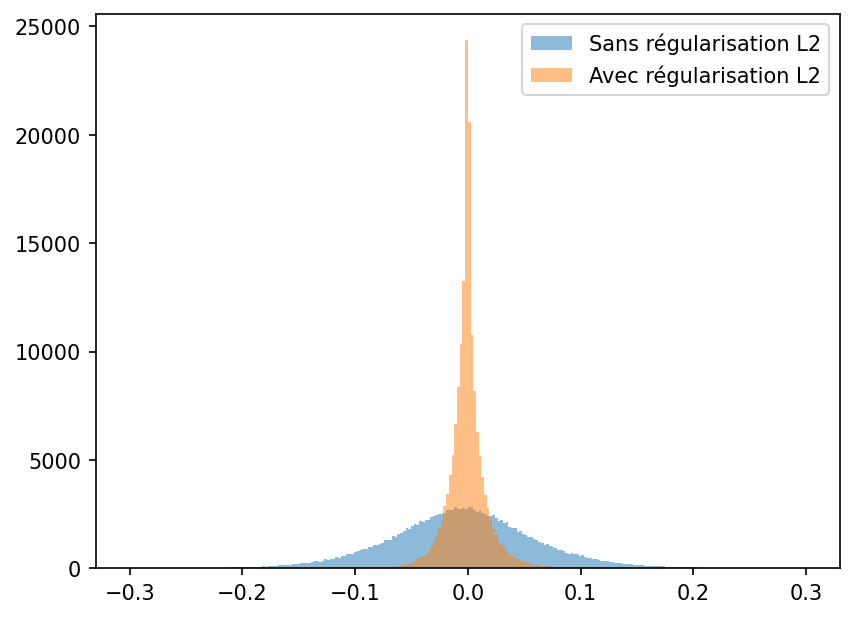

In [17]:
def net_to_weight_array(net):
    weights = []
    for p in net.parameters():
        p_numpy = p.data.cpu().numpy()
        weights.append(p_numpy.reshape((-1))) # Reshape to 1D array
    return np.concatenate(weights)

weights_without_l2 = net_to_weight_array(net_without_l2)
weights_l2 = net_to_weight_array(net_l2)

print("Poids sans régularisation L2: variance {:.4f}, maximum {:.4f}.".format(np.var(weights_without_l2),
                                                                              np.max(np.abs(weights_without_l2))))
print("Poids avec régularisation L2: variance {:.4f}, maximum {:.4f}.".format(np.var(weights_l2),
                                                                              np.max(np.abs(weights_l2))))

# Visualisation
plt.hist(weights_without_l2, bins=250, range=(-0.3, 0.3), alpha =0.5, label="Sans régularisation L2")
plt.hist(weights_l2, bins=250, range=(-0.3, 0.3), alpha=0.5, label="Avec régularisation L2")
plt.legend()
plt.show()

## Partie 2: Early stopping

Commencez par entraîner un réseau pour un grand nombre d'époques. L'historique d'entraînement nous servira de base pour les questions qui suivent.

In [18]:
torch.manual_seed(42)
net = CifarNetBatchNorm()

optimizer = optim.SGD(net.parameters(), lr=0.01, weight_decay=1e-3, nesterov=True, momentum=0.9)
scheduler = pt.ReduceLROnPlateau(monitor='val_acc', mode='max', patience=3, factor=0.5)

history = train(net, optimizer, cifar_train, n_epoch=40, batch_size=64, callbacks=[scheduler], use_gpu=True)

Epoch:  1/40 Train steps: 625 Val steps: 157 10.15s loss: 1.704904 acc: 42.785000 val_loss: 1.360389 val_acc: 51.130000
Epoch:  2/40 Train steps: 625 Val steps: 157 10.02s loss: 1.206048 acc: 57.142500 val_loss: 1.184051 val_acc: 58.870000
Epoch:  3/40 Train steps: 625 Val steps: 157 9.95s loss: 1.020285 acc: 64.127500 val_loss: 1.173586 val_acc: 58.870000
Epoch:  4/40 Train steps: 625 Val steps: 157 10.04s loss: 0.900187 acc: 68.697500 val_loss: 1.031039 val_acc: 64.900000
Epoch:  5/40 Train steps: 625 Val steps: 157 11.04s loss: 0.813489 acc: 71.750000 val_loss: 1.001920 val_acc: 66.010000
Epoch:  6/40 Train steps: 625 Val steps: 157 9.51s loss: 0.737922 acc: 74.545000 val_loss: 0.970800 val_acc: 66.860000
Epoch:  7/40 Train steps: 625 Val steps: 157 9.99s loss: 0.682125 acc: 76.425000 val_loss: 1.057815 val_acc: 63.950000
Epoch:  8/40 Train steps: 625 Val steps: 157 10.00s loss: 0.630092 acc: 78.250000 val_loss: 1.001510 val_acc: 66.100000
Epoch:  9/40 Train steps: 625 Val steps: 15

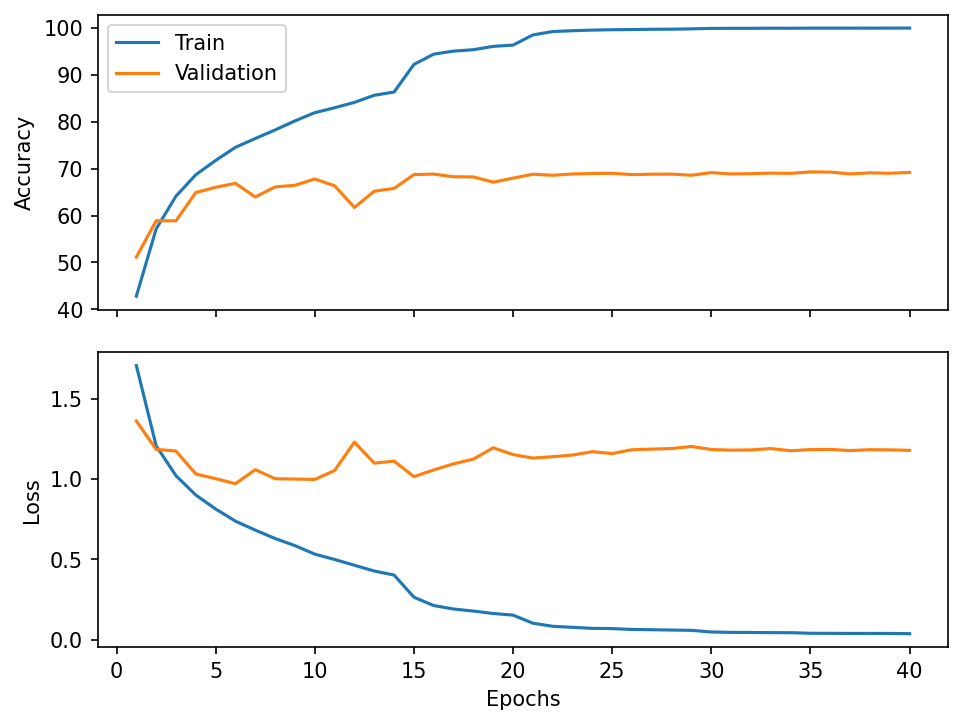

In [19]:
history.display()

#### Question
- En regardant les graphiques ci-dessus, quel est le meilleur moment pour arrêter l'entraînement?
Autour de la 20e époque, highest accuracy, doesn't learn after that.

L'algorithme 7.1 du livre (voir http://www.deeplearningbook.org/contents/regularization.html page 244) décrit le paramètre de patience `p` dans le contexte d'un algorithme de *early stopping* (**Attention**: le paramètre de patience `p` du *early stopping* n'a pas de lien avec le paramètre `p` correspondant à l'ordre d'une norme de la section précédente).

#### Exercice
- Analysez l'effet du choix de `p` sur les données de l'entraînement précédent. Regardez pour `p = 1,2,5,10,15`, quelle époque avec quelle précision en validation est choisie. Implémentez un algorithme effectuant du *early stopping* en utilisant l'historique `val_accuracy` de l'entraînement que vous venez d'exécuter pour vos tests (à la place d'entraîner le réseau).

In [24]:
# Historique
val_accuracy_history = history.history['val_acc']

# Patience
p = 15

best_val_accuracy = -np.inf
best_epoch = -1

# TODO Implémentez un algorithme de early stopping sur l'historique
for epoch in range(len(val_accuracy_history)):
  if val_accuracy_history[epoch] > best_val_accuracy:
    best_val_accuracy = val_accuracy_history[epoch]
    best_epoch = epoch
  else:
    if epoch - best_epoch > p:
      break

print("Pour patience p={}, la meilleure époque est {}, avec précision en validation de {:.2f}.".format(p, best_epoch, best_val_accuracy))

Pour patience p=15, la meilleure époque est 34, avec précision en validation de 69.30.


#### Question

- Identifiez des problèmes pratiques potentiels lors de l'utilisation du *early stopping*.

p Too low = arrête trop rapidement avant les meilleures performances réelles.
p Too high = calcule plus d'époques que nécessaire, donc compute inutile.

### Pour aller plus loin sur le early stopping
Avec Poutyne, on peut effectuer le *early stopping* automatiquement grâce au callback [EarlyStopping](https://poutyne.org/callbacks.html#poutyne.EarlyStopping). Il faut spécifier la métrique à monitorer ainsi que la patience, et on peut également contrôler l'amplitude minimum d'un changement pour que celui-ci soit qualifié comme une amélioration avec le paramètre `min_delta`. L'entraînement va donc s'arrêter automatiquement lorsqu'il n'y a plus d'amélioration pour un nombre consécutif d'époques correspondant à la patience, prévenant possiblement le calcul inutile de plusieurs époques.

In [25]:
# Patience
p = 3

torch.manual_seed(42)
net = CifarNetBatchNorm()

optimizer = optim.SGD(net.parameters(), lr=0.01, weight_decay=1e-3, nesterov=True, momentum=0.9)
scheduler = pt.ReduceLROnPlateau(monitor='val_acc', mode='max', patience=3, factor=0.5)

# Early stopping sous la forme d'un Callback
early_stopping = pt.EarlyStopping(monitor='val_acc', mode='max', min_delta=1e-5, patience=p, verbose=True)

history = train(net, optimizer, cifar_train, n_epoch=40, batch_size=64, callbacks=[scheduler, early_stopping], use_gpu=True)

Epoch:  1/40 Train steps: 625 Val steps: 157 10.09s loss: 1.705867 acc: 42.777500 val_loss: 1.349112 val_acc: 51.720000
Epoch:  2/40 Train steps: 625 Val steps: 157 10.13s loss: 1.205645 acc: 57.120000 val_loss: 1.154257 val_acc: 60.040000
Epoch:  3/40 Train steps: 625 Val steps: 157 10.02s loss: 1.020219 acc: 64.195000 val_loss: 1.133544 val_acc: 60.060000
Epoch:  4/40 Train steps: 625 Val steps: 157 10.09s loss: 0.897569 acc: 68.575000 val_loss: 1.000837 val_acc: 64.780000
Epoch:  5/40 Train steps: 625 Val steps: 157 10.09s loss: 0.812426 acc: 71.972500 val_loss: 0.985606 val_acc: 66.330000
Epoch:  6/40 Train steps: 625 Val steps: 157 10.69s loss: 0.735922 acc: 74.555000 val_loss: 1.018188 val_acc: 66.040000
Epoch:  7/40 Train steps: 625 Val steps: 157 10.11s loss: 0.681157 acc: 76.485000 val_loss: 1.037996 val_acc: 64.390000
Epoch:  8/40 Train steps: 625 Val steps: 157 10.09s loss: 0.628643 acc: 78.405000 val_loss: 0.999343 val_acc: 66.500000
Epoch:  9/40 Train steps: 625 Val steps:

## Partie 3: Dropout
Cette section a pour but d'analyser l'effet du dropout dans un réseau fully connected. Nous ferons cette analyse en reprenant l'exercice du laboratoire 2.

#### Exercice
- Dans le réseau suivant, implémentez la fonction `forward()` formée de couches linéaires suivies d'activation   `Relu` en ajoutant du dropout ([Indice](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.dropout)) après l'activation si `self.use_dropout == True` . Utilisez une probabilité de dropout de `0.3` indiqué par `self.dropout_p` et ne faites pas de dropout sur la couche de sortie. N'ajoutez **pas de softmax** car la fonction `deeplib.training.train()` utilise par défaut `CrossEntropyLoss`, ce qui le fait pour vous.

> **ATTENTION!** Vous devez bien fixer l'argument `training` de dropout. Vous pouvez savoir si modèle est en entraînement ou en évaluation avec `self.training`.

In [ ]:
class MnistModel(torch.nn.Module):

    def __init__(self, n_layers, hidden_size=100, use_dropout=True, dropout_p=0.3):
        super().__init__()
        torch.manual_seed(42)
        self.use_dropout = use_dropout
        self.hidden_size = hidden_size
        self.dropout_p = dropout_p

        # Initialisation des couches
        layer_sizes = [28*28] + [self.hidden_size]*n_layers
        self.layers = nn.ModuleList()
        for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            layer = nn.Linear(input_size, output_size)
            layer.weight.data.normal_(0.0, math.sqrt(2 / input_size))
            layer.bias.data.fill_(0)
            self.layers.append(layer)


        # Couche de sortie avec une neurone par classe
        self.output_layer = nn.Linear(hidden_size,10)
        self.output_layer.weight.data.normal_(0.0, math.sqrt(2 / hidden_size))
        self.output_layer.bias.data.fill_(0)

    def forward(self, x):
        out = x.view(-1, 28*28)
        for layer in self.layers:
            # TODO

        return self.output_layer(out)

#### Question
- Quelle est l'importance de l'argument `training` de la fonction de dropout?

Entraînez un réseau avec dropout et un réseau sans dropout.

In [ ]:
# Paramètres
lr = 0.01
batch_size = 64
n_epoch = 20

Réseau sans dropout:

In [ ]:
net_without_dropout = MnistModel(2, use_dropout=False)
optimizer_without_dropout = optim.SGD(net_without_dropout.parameters(), lr, nesterov=True, momentum=0.9)

history_without_dropout = train(net_without_dropout, optimizer_without_dropout, mnist_train, n_epoch, batch_size, use_gpu=True)
history_without_dropout.display()
print('Précision en test: {:.2f}'.format(test(net_without_dropout, mnist_test, batch_size)))

Réseau avec dropout:

In [ ]:
net_with_dropout = MnistModel(2, use_dropout=True, dropout_p=0.3)
optimizer_with_dropout = optim.SGD(net_with_dropout.parameters(), lr, nesterov=True, momentum=0.9)

history_with_dropout = train(net_with_dropout, optimizer_with_dropout, mnist_train, n_epoch, batch_size, use_gpu=True)
history_with_dropout.display()
print('Précision en test: {:.2f}'.format(test(net_with_dropout, mnist_test, batch_size)))

#### Questions
- Quel est l'effet du dropout sur l'entraînement du réseau?
    
- Essayez plusieurs valeurs de dropout et observez les effets.